# 01 — Exploratory Data Analysis

**Goal of the whole project:** forecast the water-quality indicators **NH4, COD and TSS
4 hours ahead** at three Hanoi sites (Bay Mau, Cau Nga, Ho Tay).

**Goal of this notebook:** understand the raw data *before* deciding how to clean or model it.
Every cleaning rule used in `02_data_preprocessing.ipynb` is justified by something found here.

Run order:

| # | Notebook | Purpose |
|---|---|---|
| 01 | **this one** | look at the raw files |
| 02 | `02_data_preprocessing` | clean, aggregate, choose features |
| 03 | `03_model_training` | train baselines and models |
| 04 | `04_evaluation_comparison` | compare and pick the model to keep |

## Step 1 — Imports and settings

In [1]:
import datetime as dt
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# The three sites. The key is the short name we use in code.
SITE_FILES = {
    "BAY_MAU": "BAY MAU.xlsx",
    "CAU_NGA": "CAU NGA.xlsx",
    "HO_TAY": "HO TAY.xlsx",
}
SITE_NAME = {"BAY_MAU": "Bay Mau", "CAU_NGA": "Cau Nga", "HO_TAY": "Ho Tay"}

# All columns the Excel files contain.
ALL_COLUMNS = ["flow_in", "flow_out1", "flow_out2", "flow_out3", "temp", "ph", "tss",
               "do", "cod", "bod", "toc", "no3", "nh4", "po4", "total_n", "total_p"]

# The three indicators we want to forecast.
TARGETS = ["nh4", "cod", "tss"]

# We forecast 4 hours into the future.
HORIZON_HOURS = 4

print("Forecasting", TARGETS, "at", HORIZON_HOURS, "hours ahead")

Forecasting ['nh4', 'cod', 'tss'] at 4 hours ahead


## Step 2 — Load the raw Excel files

Reading these files takes about a minute each, so the result is cached in a `cache/` folder.
Delete that folder if you ever want to force a fresh read.

In [2]:
import os
os.makedirs("cache", exist_ok=True)


def load_excel(site):
    """Read one site's Excel file, using a cached copy when available."""
    cache_file = "cache/raw_" + site + ".pkl"
    if os.path.exists(cache_file):
        return pd.read_pickle(cache_file)
    table = pd.read_excel(SITE_FILES[site])
    table.to_pickle(cache_file)
    return table


raw_data = {}
for site in SITE_FILES:
    raw_data[site] = load_excel(site)
    print(SITE_NAME[site], ":", len(raw_data[site]), "rows,",
          raw_data[site].shape[1], "columns")

Bay Mau : 90021 rows, 17 columns
Cau Nga : 77111 rows, 17 columns
Ho Tay : 63322 rows, 17 columns


## Step 3 — Which columns actually contain data?

Before using a column we should check it is not empty. One extra care is needed: Excel turned a
few cells into dates by accident. `pd.to_numeric` would convert those into huge numbers, so we
turn them into missing values first.

In [3]:
def to_number(column):
    """Turn a messy column into numbers. Dates and text become missing values."""
    no_dates = column.apply(
        lambda value: np.nan if isinstance(value, (dt.datetime, dt.date)) else value)
    return pd.to_numeric(no_dates, errors="coerce")


# Percentage of rows that are not empty, for every column and every site.
coverage = pd.DataFrame(index=ALL_COLUMNS)
for site in SITE_FILES:
    percentages = []
    for column in ALL_COLUMNS:
        if column in raw_data[site].columns:
            filled = to_number(raw_data[site][column]).notna().mean()
        else:
            filled = 0.0
        percentages.append(round(100 * filled, 1))
    coverage[SITE_NAME[site]] = percentages

print("How full is each column (% of rows)?")
coverage

How full is each column (% of rows)?


,Bay Mau,Cau Nga,Ho Tay
flow_in,99.1,0.0,100.0
flow_out1,94.4,100.0,99.9
flow_out2,92.8,0.0,0.0
flow_out3,85.1,0.0,0.0
temp,84.4,100.0,85.2
ph,69.3,100.0,82.0
tss,82.6,100.0,77.4
do,0.0,0.0,0.0
cod,80.9,100.0,80.3
bod,0.0,0.0,0.0


In [4]:
# Group the columns into three cases so the picture is easy to read.
always_empty = coverage.index[coverage.max(axis=1) == 0]
sometimes_empty = coverage.index[(coverage.max(axis=1) > 0) & (coverage.min(axis=1) == 0)]
always_present = coverage.index[coverage.min(axis=1) > 0]

print("EMPTY AT EVERY SITE - cannot be used at all:")
print("   ", list(always_empty))
print()
print("PRESENT AT SOME SITES ONLY - usable, but only where it exists:")
for column in sometimes_empty:
    have = [SITE_NAME[s] for s in SITE_FILES if coverage.loc[column, SITE_NAME[s]] > 0]
    print("   ", column, "-> available at", have)
print()
print("AVAILABLE EVERYWHERE:")
print("   ", list(always_present))

EMPTY AT EVERY SITE - cannot be used at all:
    ['do', 'bod', 'toc', 'total_n', 'total_p']

PRESENT AT SOME SITES ONLY - usable, but only where it exists:
    flow_in -> available at ['Bay Mau', 'Ho Tay']
    flow_out2 -> available at ['Bay Mau']
    flow_out3 -> available at ['Bay Mau']
    no3 -> available at ['Cau Nga', 'Ho Tay']
    po4 -> available at ['Bay Mau']

AVAILABLE EVERYWHERE:
    ['flow_out1', 'temp', 'ph', 'tss', 'cod', 'nh4']


**Finding 1.** Eight of the sixteen columns are completely empty at every site, so they can
never be used.

**Finding 2.** `no3` and `flow_in` exist at two sites but not the third. That means the feature
list should be chosen **per site** — dropping a column everywhere because one site lacks it
would throw away real information at the other two.

## Step 4 — Are the timestamps continuous?

The sensors are supposed to record every 5 minutes. If there are long holes in the record, any
gap-filling we do would be inventing data — and we must not measure a model's accuracy on
invented data.

In [5]:
gap_rows = []
for site in SITE_FILES:
    times = pd.to_datetime(raw_data[site]["datetime"], errors="coerce")
    times = times.dropna().drop_duplicates().sort_values()

    # Minutes between one reading and the next.
    minutes_between = times.diff().dt.total_seconds() / 60
    long_gaps = minutes_between[minutes_between > 10]

    # How many rows would a perfect 5-minute record contain?
    expected_rows = (times.max() - times.min()).total_seconds() / 300 + 1

    gap_rows.append({
        "site": SITE_NAME[site],
        "rows": len(times),
        "first_reading": times.min(),
        "last_reading": times.max(),
        "coverage_%": round(100 * len(times) / expected_rows, 1),
        "number_of_gaps": len(long_gaps),
        "biggest_gap_days": round(long_gaps.max() / 60 / 24, 1),
    })

gap_summary = pd.DataFrame(gap_rows).set_index("site")
gap_summary

,rows,first_reading,last_reading,coverage_%,number_of_gaps,biggest_gap_days
site,,,,,,
Bay Mau,89863,2024-01-01 00:00:00,2024-12-31 23:55:00,85.3,8,41.0
Cau Nga,76618,2024-03-13 08:25:00,2024-12-31 23:55:00,90.6,73,1.3
Ho Tay,61292,2024-03-13 08:30:00,2024-12-31 23:55:00,72.5,427,52.1


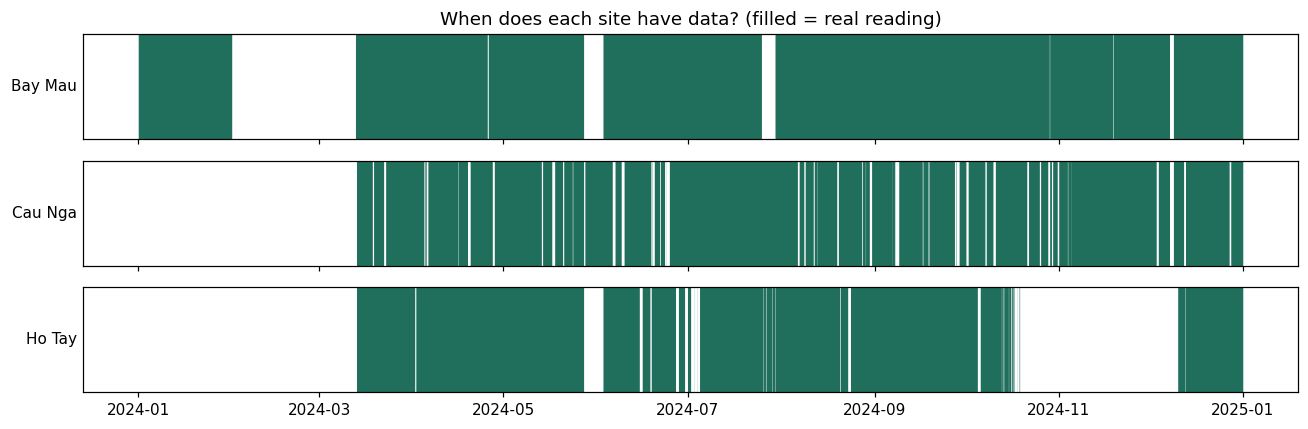

In [6]:
# Draw where data exists during 2024. A filled bar means that hour has a real reading.
whole_year = pd.date_range("2024-01-01", "2024-12-31 23:00", freq="1h")
figure, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)

for axis, site in zip(axes, SITE_FILES):
    times = pd.to_datetime(raw_data[site]["datetime"], errors="coerce").dropna()
    has_reading = pd.Series(1, index=times).resample("1h").count().gt(0).astype(int)
    has_reading = has_reading.reindex(whole_year, fill_value=0)

    axis.fill_between(has_reading.index, 0, has_reading.values, step="mid",
                      color="#1f6f5c", linewidth=0)
    axis.set_ylabel(SITE_NAME[site], rotation=0, ha="right", va="center")
    axis.set_yticks([])
    axis.set_ylim(0, 1)
    axis.grid(False)

axes[0].set_title("When does each site have data? (filled = real reading)")
plt.tight_layout()
plt.show()

**Finding 3 — the most important one in this notebook.**

Ho Tay is missing about **52 days** (19 Oct to 10 Dec) and Bay Mau about **41 days**
(Feb to 13 Mar). Real coverage is roughly 85% / 91% / 72%, not 100%.

If we fill those months with interpolation, the filled values are a straight line that we
invented. Training on them is questionable; **scoring** a model on them is meaningless. So in
notebook 02 we will keep a flag marking which values are real, and in notebook 04 we will
measure accuracy on the real ones only.

## Step 5 — Are there impossible values?

A zero can mean two completely different things, and telling them apart matters.

In [7]:
check_columns = ["temp", "ph", "tss", "cod", "nh4", "flow_out1"]

for site in SITE_FILES:
    summary = []
    for column in check_columns:
        values = to_number(raw_data[site][column])
        summary.append({
            "column": column,
            "zeros": int((values == 0).sum()),
            "negatives": int((values < 0).sum()),
            "minimum": round(values.min(), 2),
            "maximum": round(values.max(), 2),
        })
    print("---", SITE_NAME[site], "---")
    display(pd.DataFrame(summary).set_index("column"))

--- Bay Mau ---


,zeros,negatives,minimum,maximum
column,,,,
temp,4,0,0.00,35.86
ph,4,0,0.00,7.53
tss,0,0,3.61,385.84
cod,0,0,9.97,59.26
nh4,8,0,0.00,3.66
flow_out1,894,0,0.00,306.61


--- Cau Nga ---


,zeros,negatives,minimum,maximum
column,,,,
temp,6,0,0.0,33.83
ph,11,0,0.0,8.69
tss,131,0,0.0,82.05
cod,426,0,0.0,188.83
nh4,6,0,0.0,8.28
flow_out1,10397,0,0.0,1187.23


--- Ho Tay ---


,zeros,negatives,minimum,maximum
column,,,,
temp,3,0,0.0,32.22
ph,8,0,0.0,8.68
tss,1058,0,0.0,57.22
cod,4,0,0.0,57.62
nh4,5,0,0.0,4.19
flow_out1,23050,0,0.0,1591.27


**Finding 4.** There are two different kinds of zero here:

- `ph = 0` and `temp = 0` are **physically impossible**. pH 0 is battery acid, and Hanoi never
  reaches 0 degrees. These are sensor faults and must be turned into missing values. There are
  only a few per site, but a pH of 0 would badly distort any calculation that uses it.
- `flow_out1 = 0` is **completely normal** — it just means the pump is off. It is about 1%,
  13% and 36% of readings at the three sites. Deleting these would destroy a third of Ho Tay's
  flow record.

So "replace all zeros with missing" would be the wrong rule. Notebook 02 handles the two cases
separately.

## Step 6 — What do the indicators look like over time?

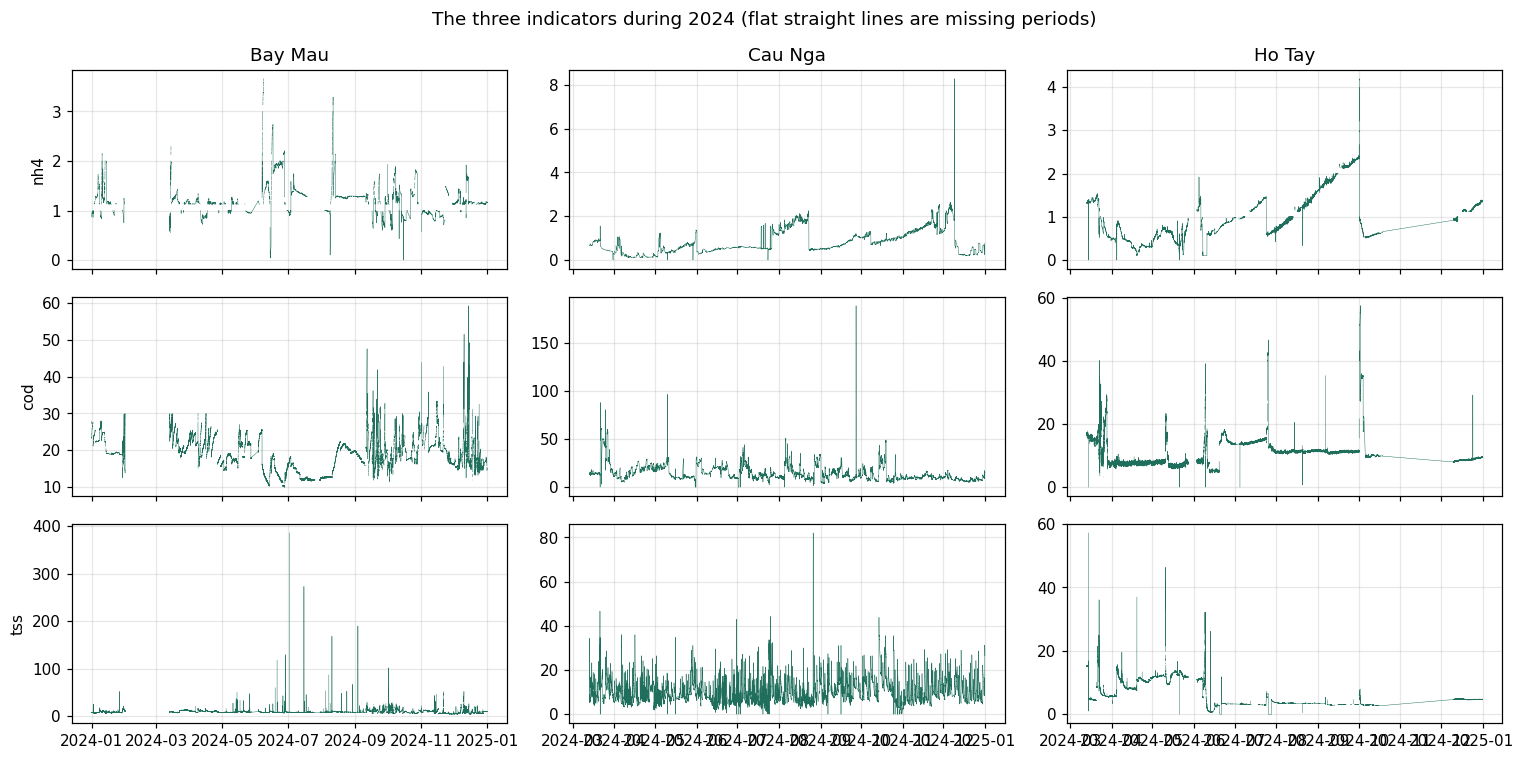

In [8]:
figure, axes = plt.subplots(3, 3, figsize=(14, 7), sharex="col")

for row, target in enumerate(TARGETS):
    for column_index, site in enumerate(SITE_FILES):
        table = raw_data[site].copy()
        table["datetime"] = pd.to_datetime(table["datetime"], errors="coerce")
        table = table.dropna(subset=["datetime"]).set_index("datetime")
        series = to_number(table[target])

        axis = axes[row, column_index]
        axis.plot(series.index, series.values, linewidth=0.3, color="#1f6f5c")
        if row == 0:
            axis.set_title(SITE_NAME[site])
        if column_index == 0:
            axis.set_ylabel(target)

plt.suptitle("The three indicators during 2024 (flat straight lines are missing periods)")
plt.tight_layout()
plt.show()

## Step 7 — How much do the indicators change in 4 hours?

This decides how hard the problem is. If a value barely moves in 4 hours, then simply saying
*"it will be the same as it is now"* is already an excellent forecast, and a complicated model
has almost nothing left to add.

For this exploration we average the readings into hours, which removes some sensor noise.

In [9]:
# A quick hourly version of the data, only for exploring.
hourly_preview = {}
for site in SITE_FILES:
    table = raw_data[site].copy()
    table["datetime"] = pd.to_datetime(table["datetime"], errors="coerce")
    table = table.dropna(subset=["datetime"]).set_index("datetime")
    for column in TARGETS:
        table[column] = to_number(table[column])
    hourly_preview[site] = table[TARGETS].resample("1h").mean()

difficulty_rows = []
for site in SITE_FILES:
    for target in TARGETS:
        series = hourly_preview[site][target]
        change_in_4h = (series.shift(-HORIZON_HOURS) - series).abs().mean()
        difficulty_rows.append({
            "site": SITE_NAME[site],
            "indicator": target,
            "typical_value": series.mean(),
            "spread_std": series.std(),
            "average_change_in_4h": change_in_4h,
            "change_divided_by_spread": change_in_4h / series.std(),
            "correlation_with_4h_later": series.corr(series.shift(HORIZON_HOURS)),
        })

difficulty = pd.DataFrame(difficulty_rows).set_index(["site", "indicator"]).round(3)
print("How much movement is there for a model to predict?")
difficulty

How much movement is there for a model to predict?


typical_value  spread_std  average_change_in_4h  change_divided_by_spread  correlation_with_4h_later
site    indicator                                                                                                      
Bay Mau nh4                1.220       0.339                 0.041                     0.121                      0.926
        cod               19.123       4.490                 0.874                     0.195                      0.874
        tss                8.727       3.369                 0.887                     0.263                      0.559
Cau Nga nh4                0.796       0.518                 0.039                     0.076                      0.973
        cod               14.633       8.228                 1.579                     0.192                      0.896
        tss                9.517       4.689                 2.591                     0.553                      0.611
Ho Tay  nh4                0.967       0.537                 0.020                     0.038                      0.989
        cod               11.227       5.216                 0.471                     0.090                      0.919
        tss                5.912       3.839                 0.212                     0.055                      0.954

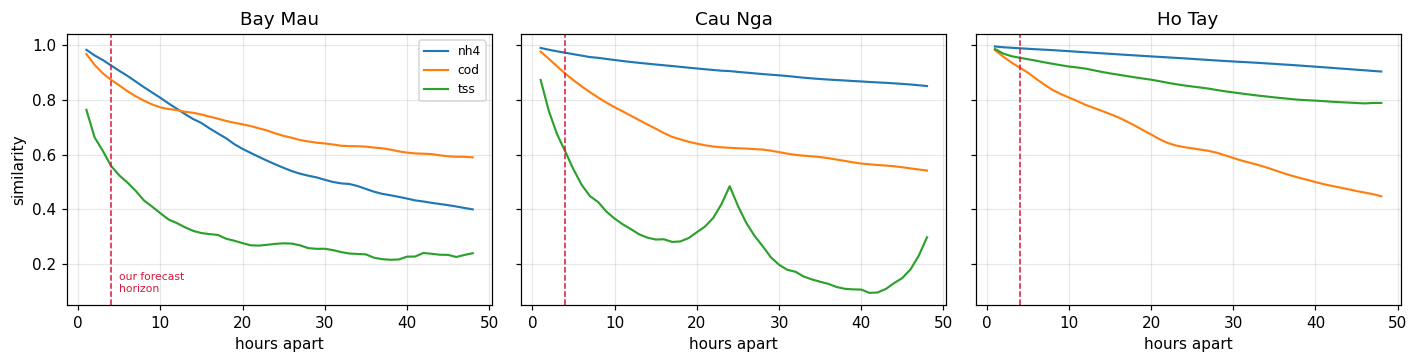

In [10]:
# How similar is a value to the value some hours later? (1.0 means identical)
figure, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)

for axis, site in zip(axes, SITE_FILES):
    for target in TARGETS:
        series = hourly_preview[site][target]
        lags = range(1, 49)
        similarity = [series.corr(series.shift(lag)) for lag in lags]
        axis.plot(lags, similarity, linewidth=1.4, label=target)

    axis.axvline(HORIZON_HOURS, color="crimson", linestyle="--", linewidth=1)
    axis.set_title(SITE_NAME[site])
    axis.set_xlabel("hours apart")

axes[0].set_ylabel("similarity")
axes[0].legend(fontsize=8)
axes[0].text(HORIZON_HOURS + 1, 0.1, "our forecast\nhorizon", color="crimson", fontsize=7)
plt.tight_layout()
plt.show()

**Finding 5.** Look at `change_divided_by_spread`. It is the typical 4-hour movement compared
with how much the series varies overall.

Where that number is small, the indicator hardly moves in 4 hours. NH4 in particular has a
4-hour similarity of about 0.89 to 0.99, meaning the value now and the value in 4 hours are
almost the same number. Any model will score well there, but only because the question is easy.

This is exactly why notebook 04 compares every model against a "no change" baseline instead of
just reporting accuracy on its own.

## Step 8 — Which columns help predict which indicator?

Rather than guessing which columns to feed the model, we measure it: how strongly does each
column, as measured **now**, relate to each indicator **4 hours from now**?

In [11]:
candidate_columns = ["temp", "ph", "tss", "cod", "nh4", "no3", "flow_in", "flow_out1"]

for site in SITE_FILES:
    table = raw_data[site].copy()
    table["datetime"] = pd.to_datetime(table["datetime"], errors="coerce")
    table = table.dropna(subset=["datetime"]).set_index("datetime")
    for column in candidate_columns:
        table[column] = to_number(table[column])
    hourly = table[candidate_columns].resample("1h").mean()

    correlations = pd.DataFrame(index=candidate_columns)
    for target in TARGETS:
        future_target = hourly[target].shift(-HORIZON_HOURS)
        correlations[target] = [hourly[c].corr(future_target) for c in candidate_columns]

    print("---", SITE_NAME[site], ": correlation with the indicator 4 hours later ---")
    display(correlations.round(3))

--- Bay Mau : correlation with the indicator 4 hours later ---


,nh4,cod,tss
temp,-0.164,0.090,0.183
ph,-0.037,-0.263,-0.010
tss,-0.147,0.251,0.559
cod,-0.297,0.874,0.217
nh4,0.926,-0.295,-0.125
no3,NaN,NaN,NaN
flow_in,0.020,-0.078,-0.053
flow_out1,-0.091,0.003,-0.015


--- Cau Nga : correlation with the indicator 4 hours later ---


,nh4,cod,tss
temp,0.020,0.191,-0.109
ph,0.185,0.023,0.250
tss,0.041,0.193,0.611
cod,-0.184,0.896,0.145
nh4,0.973,-0.174,0.063
no3,0.020,-0.122,-0.096
flow_in,NaN,NaN,NaN
flow_out1,-0.068,0.070,-0.078


--- Ho Tay : correlation with the indicator 4 hours later ---


,nh4,cod,tss
temp,0.074,0.090,-0.241
ph,0.550,0.196,-0.394
tss,-0.438,-0.211,0.954
cod,0.163,0.919,-0.247
nh4,0.989,0.186,-0.428
no3,-0.182,-0.120,0.275
flow_in,-0.060,0.068,0.105
flow_out1,0.065,-0.074,-0.031


**Finding 6.** The flow columns (`flow_in`, `flow_out1`) show correlations close to zero with
every indicator at every site. Feeding them to a model adds noise, not information.

Notebook 02 turns this into a rule: keep a column only if its correlation is at least 0.10 in
size, decided separately for each site and each indicator.

## Summary — what this notebook tells notebook 02 to do

| # | Finding | What preprocessing must do |
|---|---|---|
| 1 | 8 of 16 columns are always empty | ignore them |
| 2 | `no3` and `flow_in` exist at only some sites | choose features per site |
| 3 | 41-day and 52-day holes in the record | mark which values are real; never score on invented ones |
| 4 | `ph=0` impossible, `flow=0` normal | remove only the impossible ones |
| 5 | indicators barely move in 4 hours | always compare models against a "no change" baseline |
| 6 | flow columns show no relationship | select features by measured correlation |

Next: **`02_data_preprocessing.ipynb`**.